# Model Fitness — Análise de Rotatividade de Clientes

Este projeto analisa o perfil de clientes de uma rede de academias com o objetivo de prever rotatividade (*churn*) e desenvolver estratégias de retenção.

O conjunto de dados contém 4.000 registros e 14 variáveis, incluindo dados demográficos, comportamentais e contratuais dos clientes.

**O projeto está estruturado em cinco etapas:**

- Passo 1 — Carregamento e inspeção dos dados
- Passo 2 — Análise Exploratória dos Dados (AED)
- Passo 3 — Modelagem preditiva (Regressão Logística e Random Forest)
- Passo 4 — Clusterização de clientes (K-Means)
- Passo 5 — Conclusões e recomendações

## Passo 1 — Carregamento dos Dados

In [85]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
plt.style.use('dark_background')

df = pd.read_csv('gym_churn_us.csv')
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [86]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

## Passo 2 — Análise Exploratória dos Dados (AED)

Nesta etapa, investigamos a estrutura e o comportamento do conjunto de dados antes de qualquer modelagem.

**O que foi verificado:**

- Ausência de valores nulos em todas as 14 variáveis
- Estatísticas descritivas gerais com `describe()`
- Comparação de médias entre clientes retidos e desistentes com `groupby()`
- Distribuição visual das variáveis por grupo de churn (histogramas)
- Relações entre variáveis (matriz de correlação)

**Taxa de churn geral: 26%** — aproximadamente 1 em cada 4 clientes abandona a academia mensalmente, o que justifica o desenvolvimento de uma estratégia de retenção baseada em dados.

In [87]:
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [88]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [89]:
churn_groups = df.groupby(df['Churn']).mean()

In [90]:
churn_groups

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


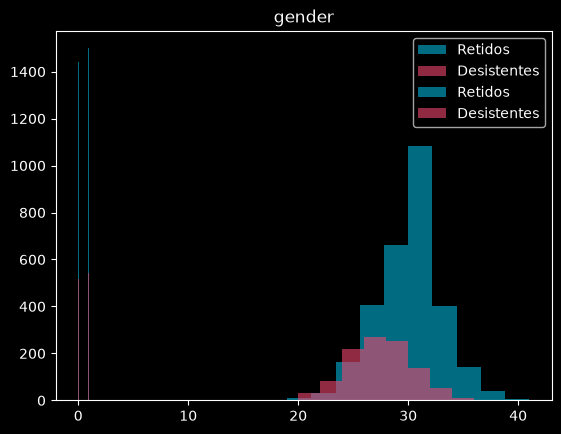

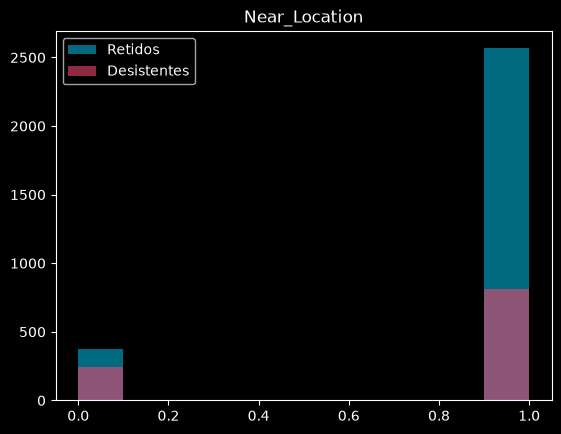

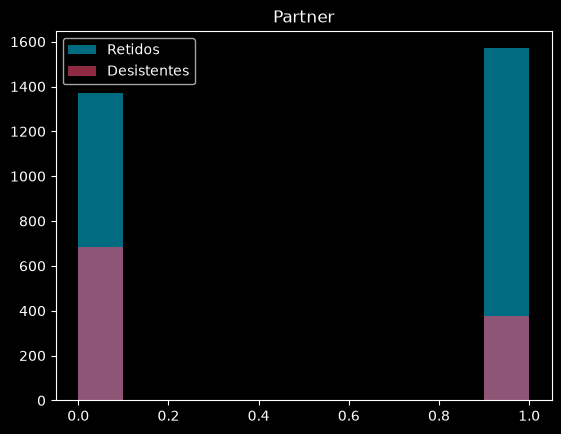

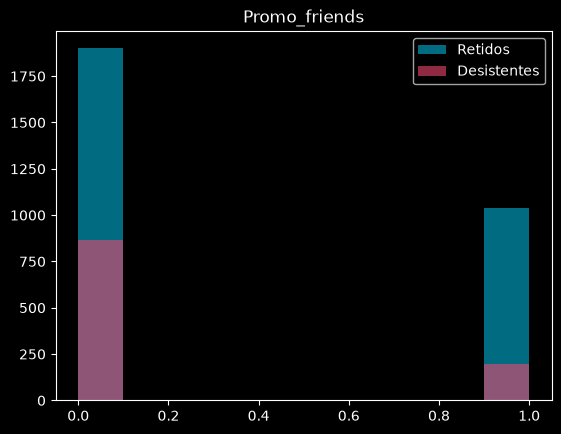

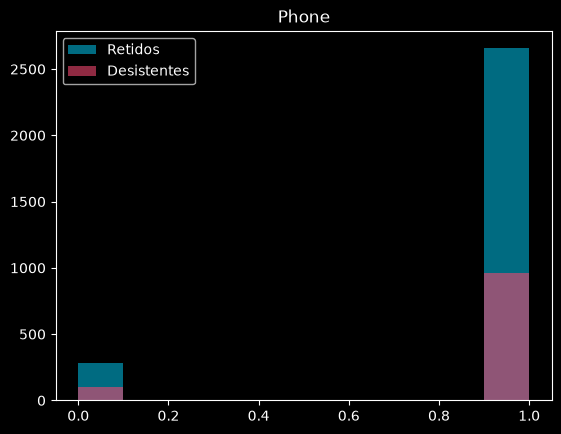

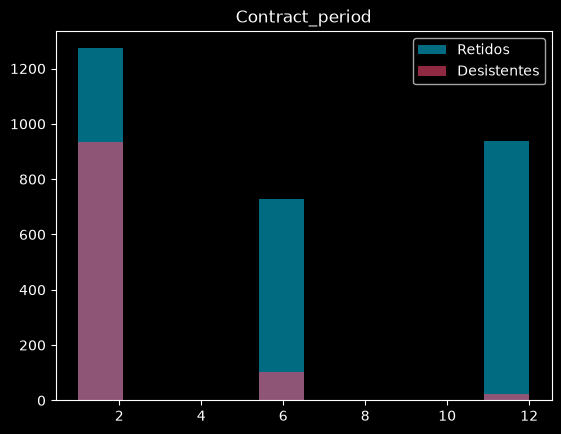

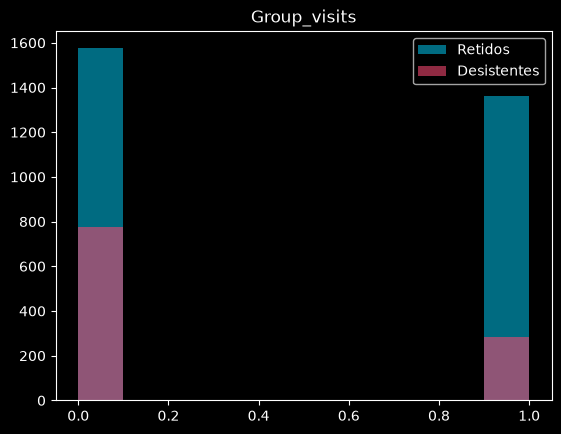

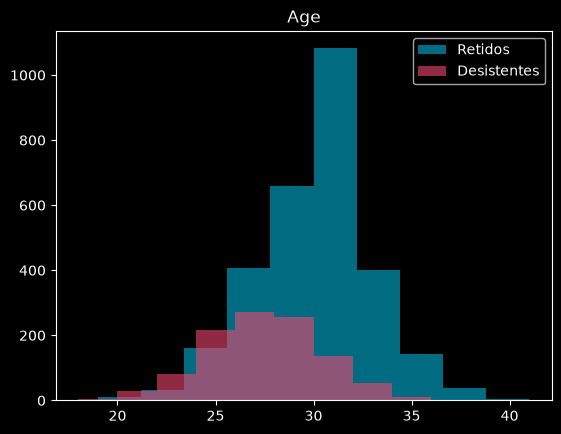

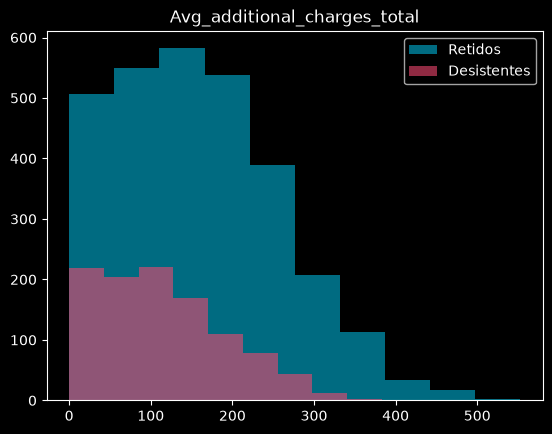

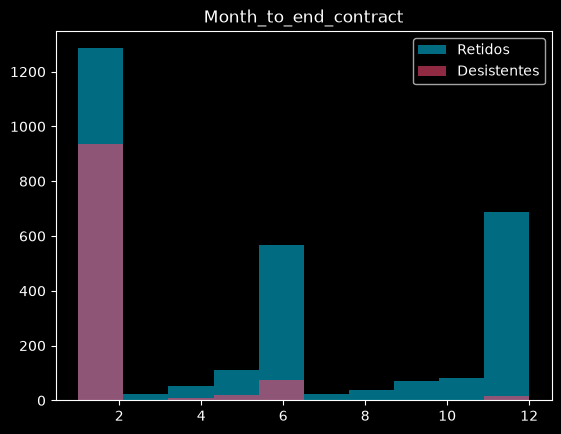

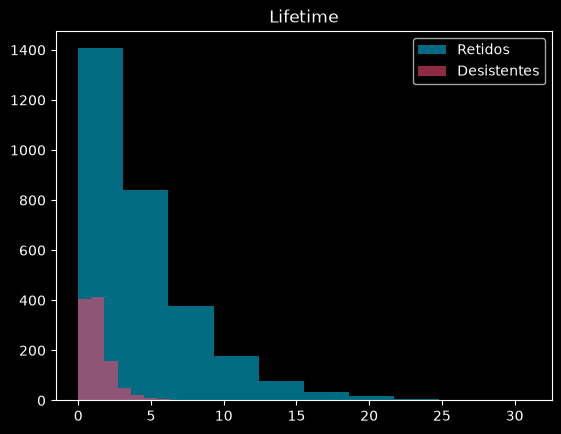

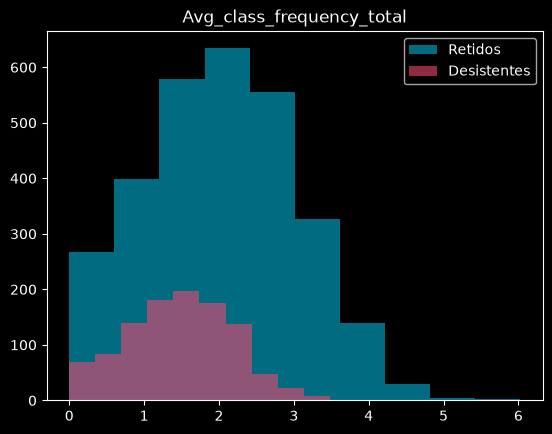

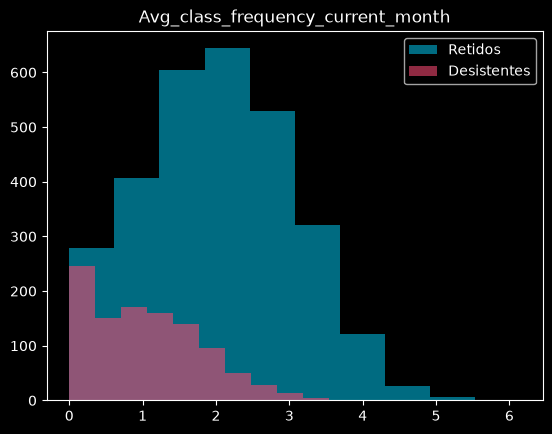

In [ ]:
features = df.columns.drop('Churn')

for col in features:
    plt.hist(df[df['Churn'] == 0][col], alpha=0.6,
             label='Retidos', color='#00B4D8')
    plt.hist(df[df['Churn'] == 1][col], alpha=0.6,
             label='Desistentes', color='#EF476F')
    plt.title(col)
    plt.legend()
    plt.show()

### Observações — Estatísticas Descritivas e Comparação entre Grupos

A taxa média de churn é de **26%** — alta para o setor, o que justifica a análise.

A comparação entre grupos revelou padrões claros:

- Clientes com **contratos mais longos** apresentam menor churn. O vínculo contratual parece funcionar como âncora de retenção
- Quanto **menos tempo resta no contrato**, maior o risco de saída — o cliente não renova e some silenciosamente
- Clientes **novos** (Lifetime baixo) desistem mais. Quem já está há mais tempo criou o hábito
- A **frequência no mês atual** é um sinal de alerta imediato — quem vai menos de duas vezes por semana tende a desistir
- Clientes que participam de **sessões em grupo** e que vieram por **indicação de amigos** tendem a ser mais fiéis

<Axes: >

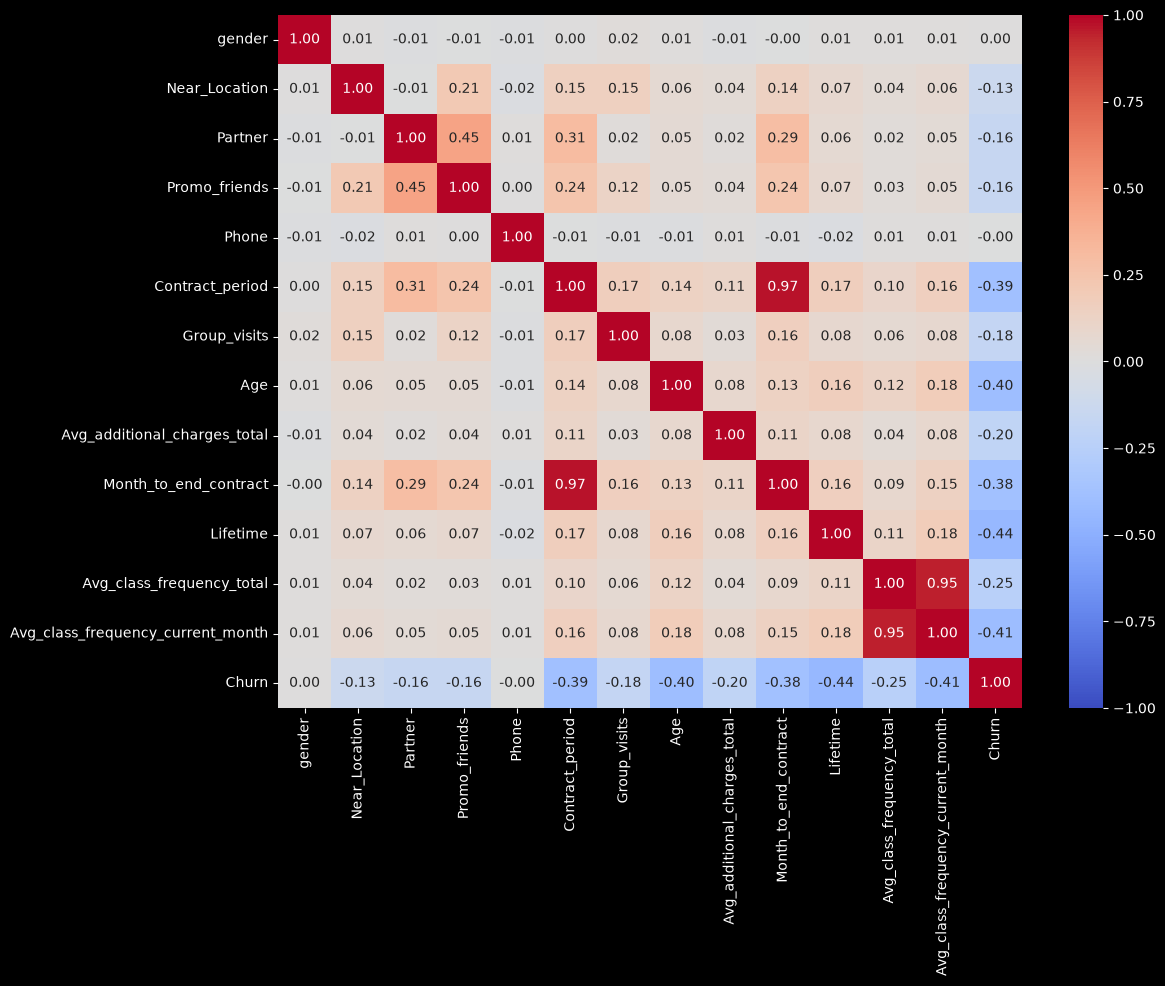

In [92]:
corr = df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

### Observações — Matriz de Correlação

A matriz revelou dois padrões relevantes:

**Multicolinearidade entre variáveis:**
- `Contract_period` e `Month_to_end_contract` apresentam correlação de ~0.97 — andam praticamente juntas
- `Avg_class_frequency_total` e `Avg_class_frequency_current_month` apresentam correlação de ~0.95

Isso indica redundância de informação entre esses pares, o que pode impactar a interpretação dos coeficientes na Regressão Logística.

**Correlação com Churn:**
- Todas as correlações com `Churn` são negativas — quanto maior o valor de qualquer variável relevante, menor a chance de desistência
- A variável com maior impacto negativo sobre o churn é o **Lifetime**: clientes com pouco tempo de academia são os mais vulneráveis à desistência

## Passo 3 — Modelagem Preditiva

Dois modelos de classificação binária foram treinados para prever o churn do mês seguinte, com divisão 80/20 entre treino e teste (`random_state=88`).

| Métrica | Regressão Logística | Random Forest |
|--------|-------------------|---------------|
| Acurácia | 0.9175 | 0.9138 |
| Precisão | 0.8380 | 0.8488 |
| Recall | **0.8538** | 0.8208 |

**Modelo escolhido: Regressão Logística**

No contexto de retenção de clientes, o **recall** é a métrica mais relevante — queremos identificar o máximo possível de clientes propensos a sair, mesmo que isso gere alguns alarmes falsos. O custo de abordar um cliente que ficaria de qualquer jeito é muito menor do que o custo de ignorar alguém que estava prestes a abandonar a academia.

A Regressão Logística apresentou recall superior (85,4% vs 82,1%), justificando sua escolha como modelo principal.

In [93]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=88)
model_lr = LogisticRegression(max_iter=4000)
model_lr = model_lr.fit(X_train, y_train)
trained_lr = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, trained_lr)

In [95]:
print('Acurácia:', accuracy_score(y_test, trained_lr))
print('Precisão:', precision_score(y_test, trained_lr))
print('Recall:', recall_score(y_test, trained_lr))

Acurácia: 0.9175
Precisão: 0.8379629629629629
Recall: 0.8537735849056604


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=88)
model_rfc = RandomForestClassifier(random_state=88)
model_rfc = model_rfc.fit(X_train, y_train)
trained_rfc = model_rfc.predict(X_test)
accuracy = accuracy_score(y_test, trained_rfc)

In [97]:
print('Acurácia:', accuracy_score(y_test, trained_rfc))
print('Precisão:', precision_score(y_test, trained_rfc))
print('Recall:', recall_score(y_test, trained_rfc))

Acurácia: 0.91375
Precisão: 0.848780487804878
Recall: 0.8207547169811321


## Passo 4 — Clusterização de Clientes

Os 4.000 clientes foram agrupados em 5 clusters via K-Means (`n_clusters=5`, `random_state=88`), 
aplicado sobre os dados padronizados pelo `StandardScaler`.

### Taxa de Churn por Cluster

| Cluster | Taxa de Churn | Perfil |
|---------|--------------|--------|
| 0 | 2,8% | **Mais fiel** |
| 1 | 26,8% | Médio |
| 2 | **51,8%** | Alto risco |
| 3 | 44,4% | Alto risco |
| 4 | 6,8% | Fiel |

### Observações

- **Clusters 0 e 4** — clientes com contratos longos, lifetime elevado e frequência consistente. 
Baixíssimo churn. São a base saudável da academia.

- **Cluster 2** — perfil de maior risco: lifetime curtíssimo (maioria abaixo de 6 meses), 
contrato prestes a vencer e menor frequência atual. Cliente novo que nunca criou o hábito 
e está prestes a sair silenciosamente.

- **Cluster 3** — também crítico: contrato quase no fim, frequência baixa. 
Diferencia-se do cluster 2 por ter um lifetime ligeiramente maior — 
cliente que já esteve engajado mas perdeu o ritmo.

- A análise confirma o padrão identificado na AED.

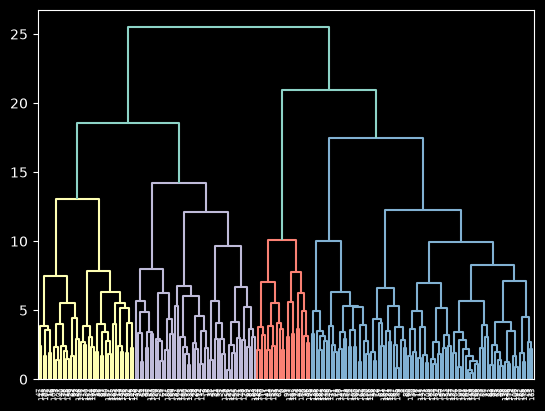

In [98]:
scaler = StandardScaler()
df_std = scaler.fit_transform(X)
df_sample = df_std[:200]
linked = linkage(df_sample, method='ward')
dendrogram(linked)
plt.show()

In [99]:
kmeans = KMeans(n_clusters=5, random_state=88)
clusters = kmeans.fit_predict(df_std)

In [100]:
df['Cluster'] = clusters

In [101]:
cluster_mean = df.groupby('Cluster').mean()
print(cluster_mean)

           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.507307       0.946764  0.742171       0.517745  0.900835   
1        0.479716       1.000000  0.000000       0.091278  0.908722   
2        0.491781       1.000000  0.986301       0.579452  0.894521   
3        0.580231       0.973042  0.335045       0.234917  0.899872   
4        0.495430       0.000000  0.466179       0.076782  0.915905   

         Contract_period  Group_visits        Age  \
Cluster                                             
0              11.736952      0.561587  29.943633   
1               1.846856      0.358012  28.289047   
2               2.915068      0.367123  28.668493   
3               2.958922      0.478819  30.356868   
4               2.243144      0.213894  28.486289   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                                                 

In [102]:
churn_mean = df.groupby('Cluster')['Churn'].mean()
churn_mean

Cluster
0    0.020877
1    0.520284
2    0.354795
3    0.030809
4    0.447898
Name: Churn, dtype: float64

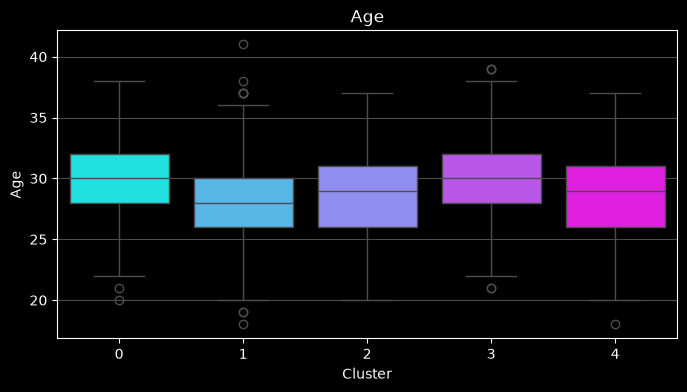

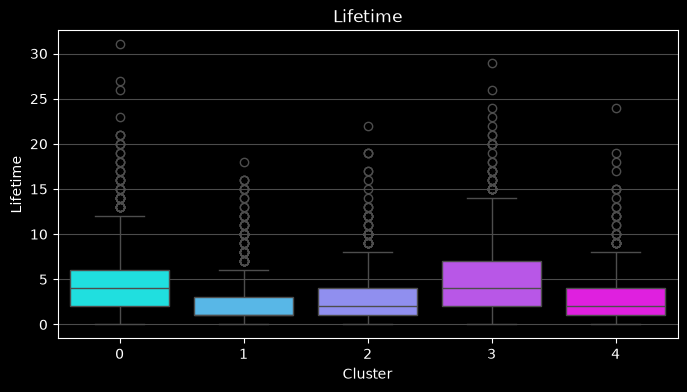

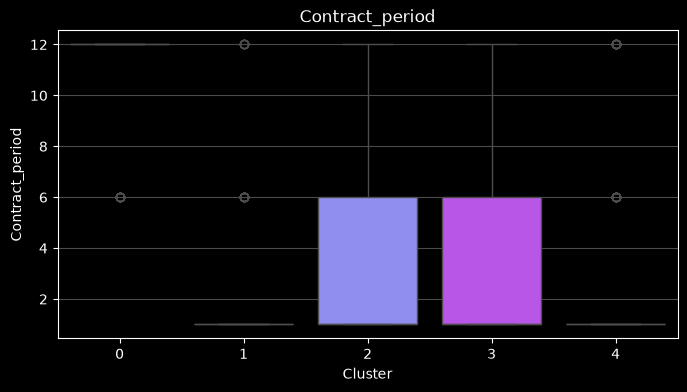

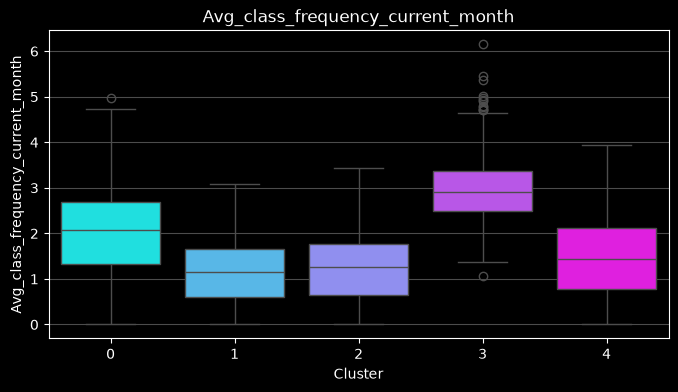

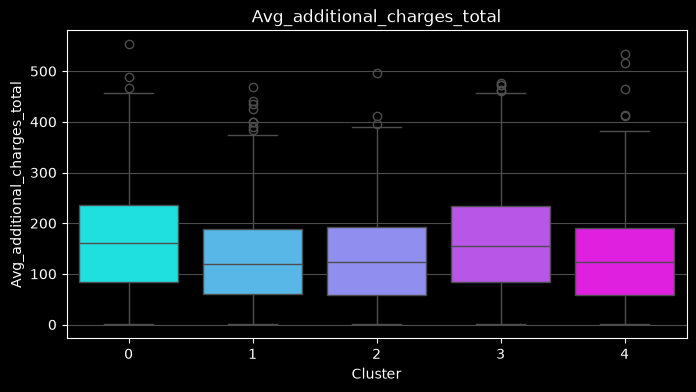

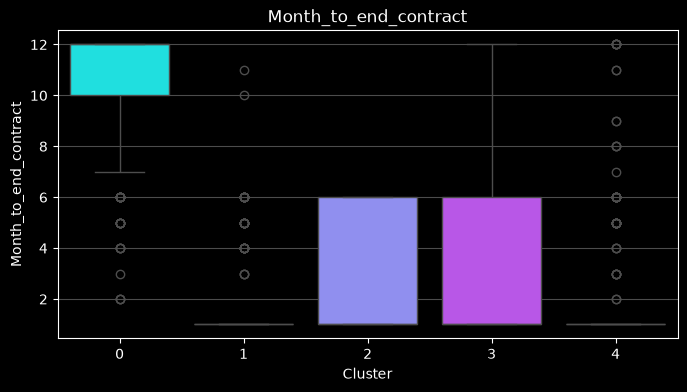

In [ ]:
key_features = ['Age', 'Lifetime', 'Contract_period',
                'Avg_class_frequency_current_month',
                'Avg_additional_charges_total',
                'Month_to_end_contract']

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Cluster', y=col, hue='Cluster',
                palette='cool', legend=False)
    plt.title(col)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Passo 5 — Conclusões e Recomendações

### Conclusões

A retenção na Model Fitness é determinada por três fatores principais, 
identificados tanto na AED quanto na clusterização:

- **Duração do contrato** — contratos longos criam compromisso e reduzem o churn
- **Tempo de casa (Lifetime)** — clientes antigos criaram o hábito; 
os novos são os mais vulneráveis
- **Frequência atual** — queda na frequência é o sinal de alerta mais imediato

A Regressão Logística previu o churn com **Acurácia de 91,7%** e **Recall de 85,3%**, 
sendo o modelo escolhido por minimizar falsos negativos — 
clientes em risco que passariam despercebidos.

Os clusters 2 e 3 concentram os clientes de maior risco: 
contratos prestes a vencer, baixo lifetime e frequência em queda.

**Nota técnica:** as variáveis `Contract_period` e `Month_to_end_contract` (aprox. 0.97) 
e `Avg_class_frequency_total` e `current_month` (aprox. 0.95) apresentam alta multicolinearidade. 
Em projetos futuros, consolidar esses pares reduziria a redundância do modelo.

### Recomendações

**1. Incentivar renovação antecipada e contratos longos**
Oferecer descontos progressivos para contratos mais longos e renovações antecipadas. 
Brindes de qualidade (toalha, shaker) podem reforçar o vínculo no momento da renovação. 
Foco nos clusters 2 e 3, onde os contratos estão prestes a vencer.

**2. Programa de fidelidade por tempo de casa**
Quanto mais tempo o aluno permanece na academia, maior o desconto acumulado — 
similar ao bônus de seguros sem sinistro. Bônus adicionais para frequência ininterrupta 
reforçam o hábito nos primeiros meses, período crítico de abandono.

**3. Incentivar aulas em grupo**
Descontos para planos com aulas coletivas reduzem o churn 
(clientes de grupo são mais fiéis) e otimizam custos fixos com instrutores. 
Conteúdo informativo mostrando resultados de alunos veteranos pode engajar 
o público mais jovem sem depender apenas de descontos.

**4. Programa de indicação**
Desconto para quem trouxer um amigo, cônjuge ou colega. 
Clientes que vieram por indicação (`Promo_friends`) já demonstram 
maior taxa de retenção nos dados — expandir esse canal é de baixo custo 
e alto impacto.